In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import pprint
from matplotlib import style

%matplotlib inline

In [4]:
df = pd.read_csv("C:\\Users\\FSHHXS2\\Desktop\\Energy DA\\ENTSO-e Data Pro 5\\monthly_hourly_load_values_2024\\monthly_hourly_load_values_2024.csv")

In [5]:
df = df[df['CountryCode'] == 'NL']
df = df.filter(items = ['DateUTC', 'Value'])

print("="*50)
print("First Five Rows ","\n")
print(df.head(5),"\n")

print("="*50)
print("Information About Dataset","\n")
print(df.info(),"\n")

print("="*50)
print("Describe the Dataset ","\n")
print(df.describe(),"\n")

print("="*50)
print("Null Values t ","\n")
print(df.isnull().sum(),"\n")

First Five Rows  

              DateUTC       Value
226206  1/1/2024 0:00  11242.1400
226207  1/1/2024 1:00  11019.3500
226208  1/1/2024 2:00  10775.8475
226209  1/1/2024 3:00  10627.0550
226210  1/1/2024 4:00  10678.3000 

Information About Dataset 

<class 'pandas.core.frame.DataFrame'>
Index: 8784 entries, 226206 to 234989
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DateUTC  8784 non-null   object 
 1   Value    8784 non-null   float64
dtypes: float64(1), object(1)
memory usage: 205.9+ KB
None 

Describe the Dataset  

              Value
count   8784.000000
mean   13096.971261
std     1962.738748
min     9134.642500
25%    11481.893125
50%    12955.832500
75%    14279.566875
max    19477.155000 

Null Values t  

DateUTC    0
Value      0
dtype: int64 



In [6]:
# Extract all Data Like Year Month Day Time etc

df["Date"] = pd.to_datetime(df["DateUTC"], format='mixed', dayfirst=True).dt.date
df["Time"] = pd.to_datetime(df["DateUTC"], format='mixed', dayfirst=True).dt.time
df["Month"] = pd.to_datetime(df["DateUTC"], format='mixed', dayfirst=True).dt.month_name()
df["Year"] = pd.to_datetime(df["DateUTC"], format='mixed', dayfirst=True).dt.year
df["Day"] = pd.to_datetime(df["DateUTC"], format='mixed', dayfirst=True).dt.day_name()
df = df.set_index("DateUTC")
df.index = pd.to_datetime(df.index, format='mixed', dayfirst=True)
df.head(3)

,Value,Date,Time,Month,Year,Day
DateUTC,,,,,,
2024-01-01 00:00:00,11242.1400,2024-01-01,00:00:00,January,2024,Monday
2024-01-01 01:00:00,11019.3500,2024-01-01,01:00:00,January,2024,Monday
2024-01-01 02:00:00,10775.8475,2024-01-01,02:00:00,January,2024,Monday


In [7]:
# How many Unique Year do we Have in Dataset 
print(df.Year.unique(),"\n")
print("Total Number of Unique Year", df.Year.nunique(), "\n")

[2024] 

Total Number of Unique Year 1 



In [8]:
Yealy_Consumption_Overview = df.groupby('Month')['Value'].agg(['max', 'mean','min'])
Yealy_Consumption_Overview

,max,mean,min
Month,,,
April,15513.6050,12358.024139,9712.6650
August,14890.4325,12278.761841,9664.8775
December,18942.2200,14577.382292,10393.5325
February,18512.4825,14032.057094,10667.3100
January,19477.1550,14733.937419,10627.0550
July,15015.3400,12210.375753,9440.1625
June,14330.0950,11900.163021,9134.6425
March,16963.3250,12982.919536,10139.5675
May,14789.7125,11989.424140,9347.1150


Text(0.5, 1.0, 'Energy Distribution')

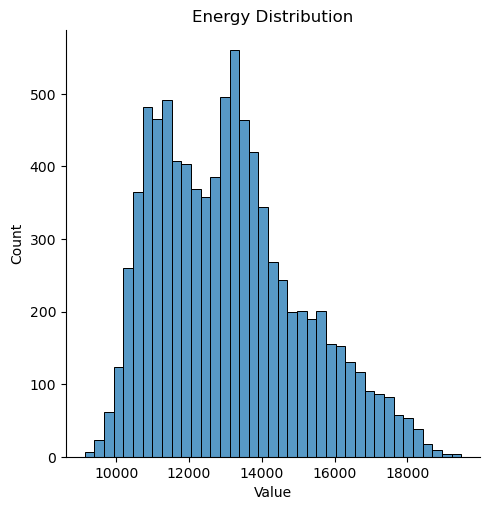

In [9]:
sns.displot(df["Value"])
plt.title("Energy Distribution")

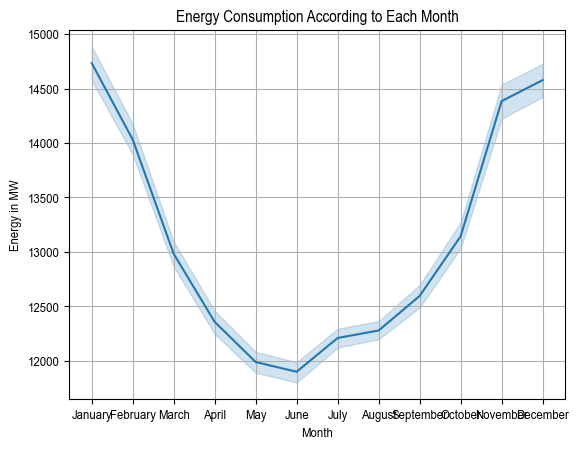

In [10]:
sns.lineplot(x=df["Month"], y=df["Value"], data=df)
sns.set(rc={'figure.figsize':(15,6)})
plt.title("Energy Consumption According to Each Month")
plt.xlabel("Month")
plt.ylabel("Energy in MW")
plt.xticks(range(0, 12))  # Shows months 1 through 12
plt.grid(True)

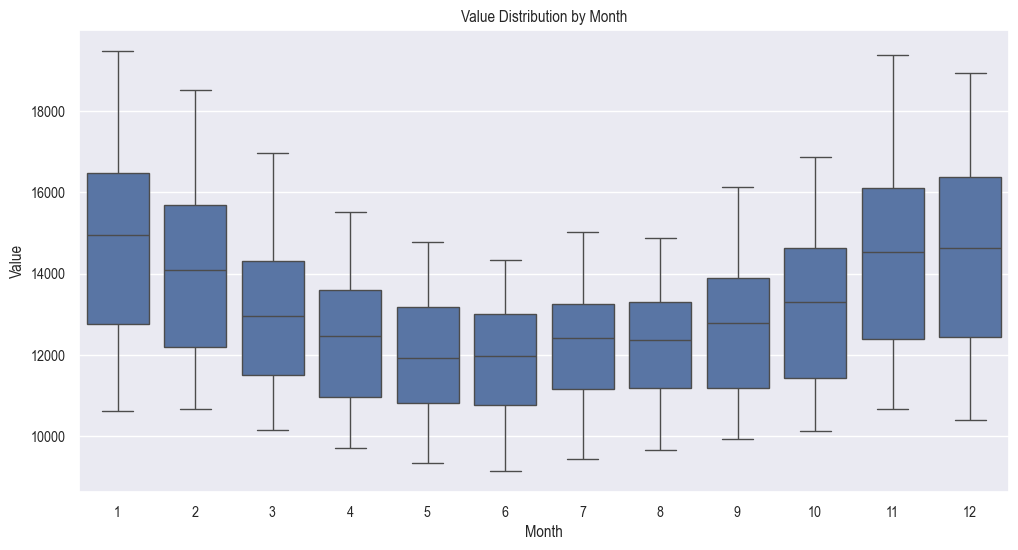

In [11]:
# Boxplot is better for categorical months
plt.figure(figsize=(12, 6))
sns.boxplot(x=df.index.month, y=df['Value'])
plt.title("Value Distribution by Month")
plt.xlabel("Month")
plt.ylabel("Value")
plt.show()

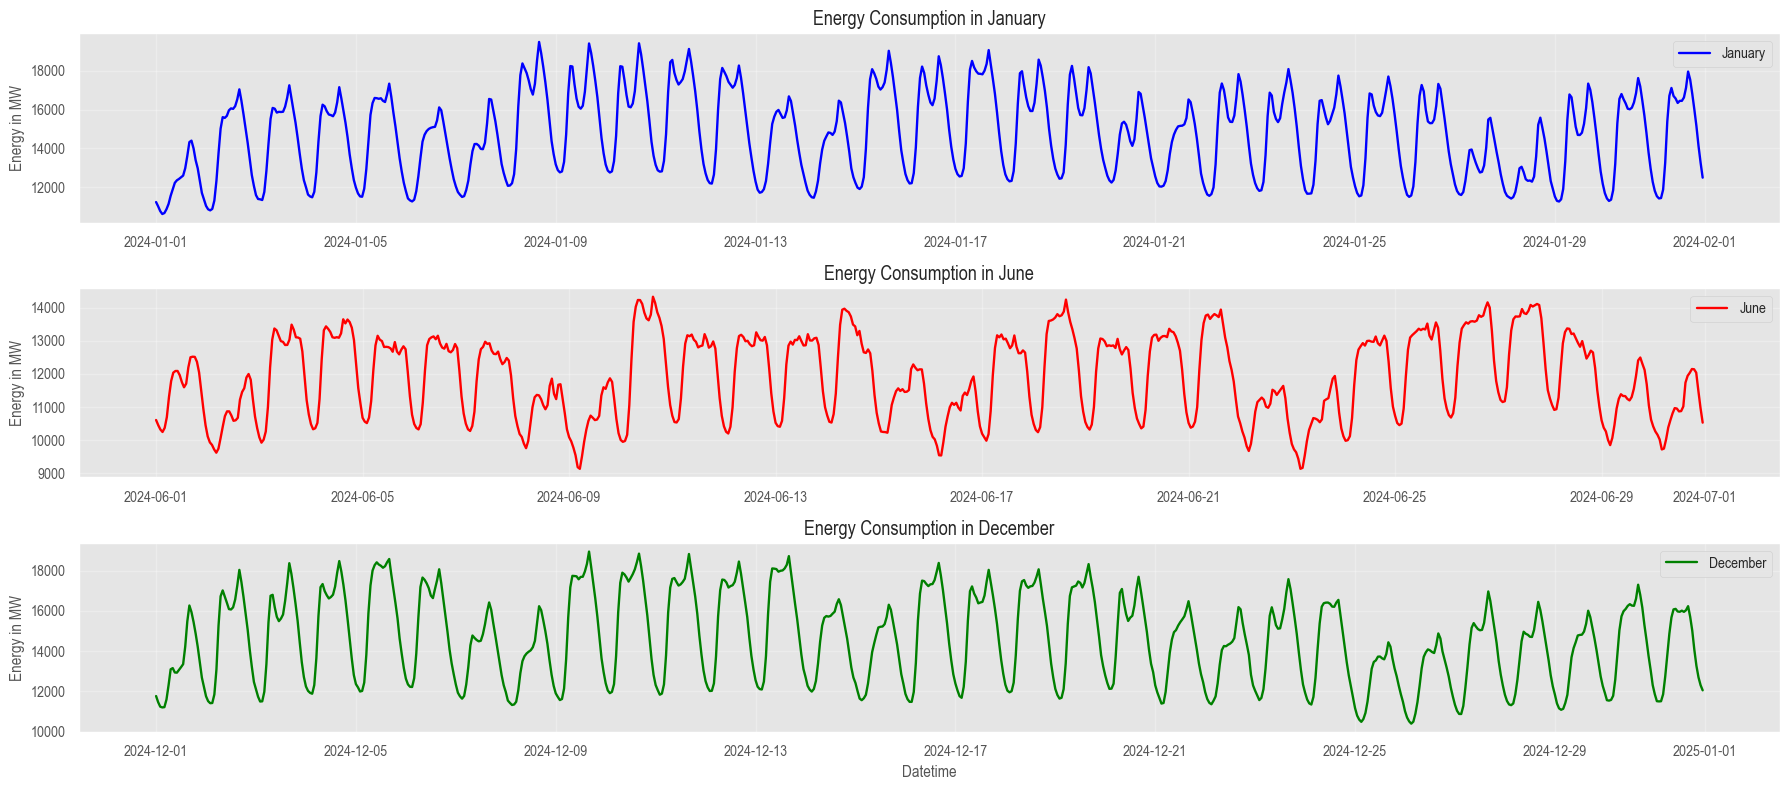

In [12]:
from matplotlib import style
style.use('ggplot')

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 8))

# Use datetime index month numbers for filtering
ax1.plot(df[df.index.month == 1].index, df[df.index.month == 1]['Value'], 
         color="blue", linewidth=1.7, label="January")
ax2.plot(df[df.index.month == 6].index, df[df.index.month == 6]['Value'], 
         color="red", linewidth=1.7, label="June")
ax3.plot(df[df.index.month == 12].index, df[df.index.month == 12]['Value'], 
         color="green", linewidth=1.7, label="December")

# Add titles and labels
ax1.set_title("Energy Consumption in January")
ax2.set_title("Energy Consumption in June") 
ax3.set_title("Energy Consumption in December")
ax3.set_xlabel("Datetime")
ax1.set_ylabel("Energy in MW")
ax2.set_ylabel("Energy in MW")
ax3.set_ylabel("Energy in MW")

for ax in [ax1, ax2, ax3]:
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

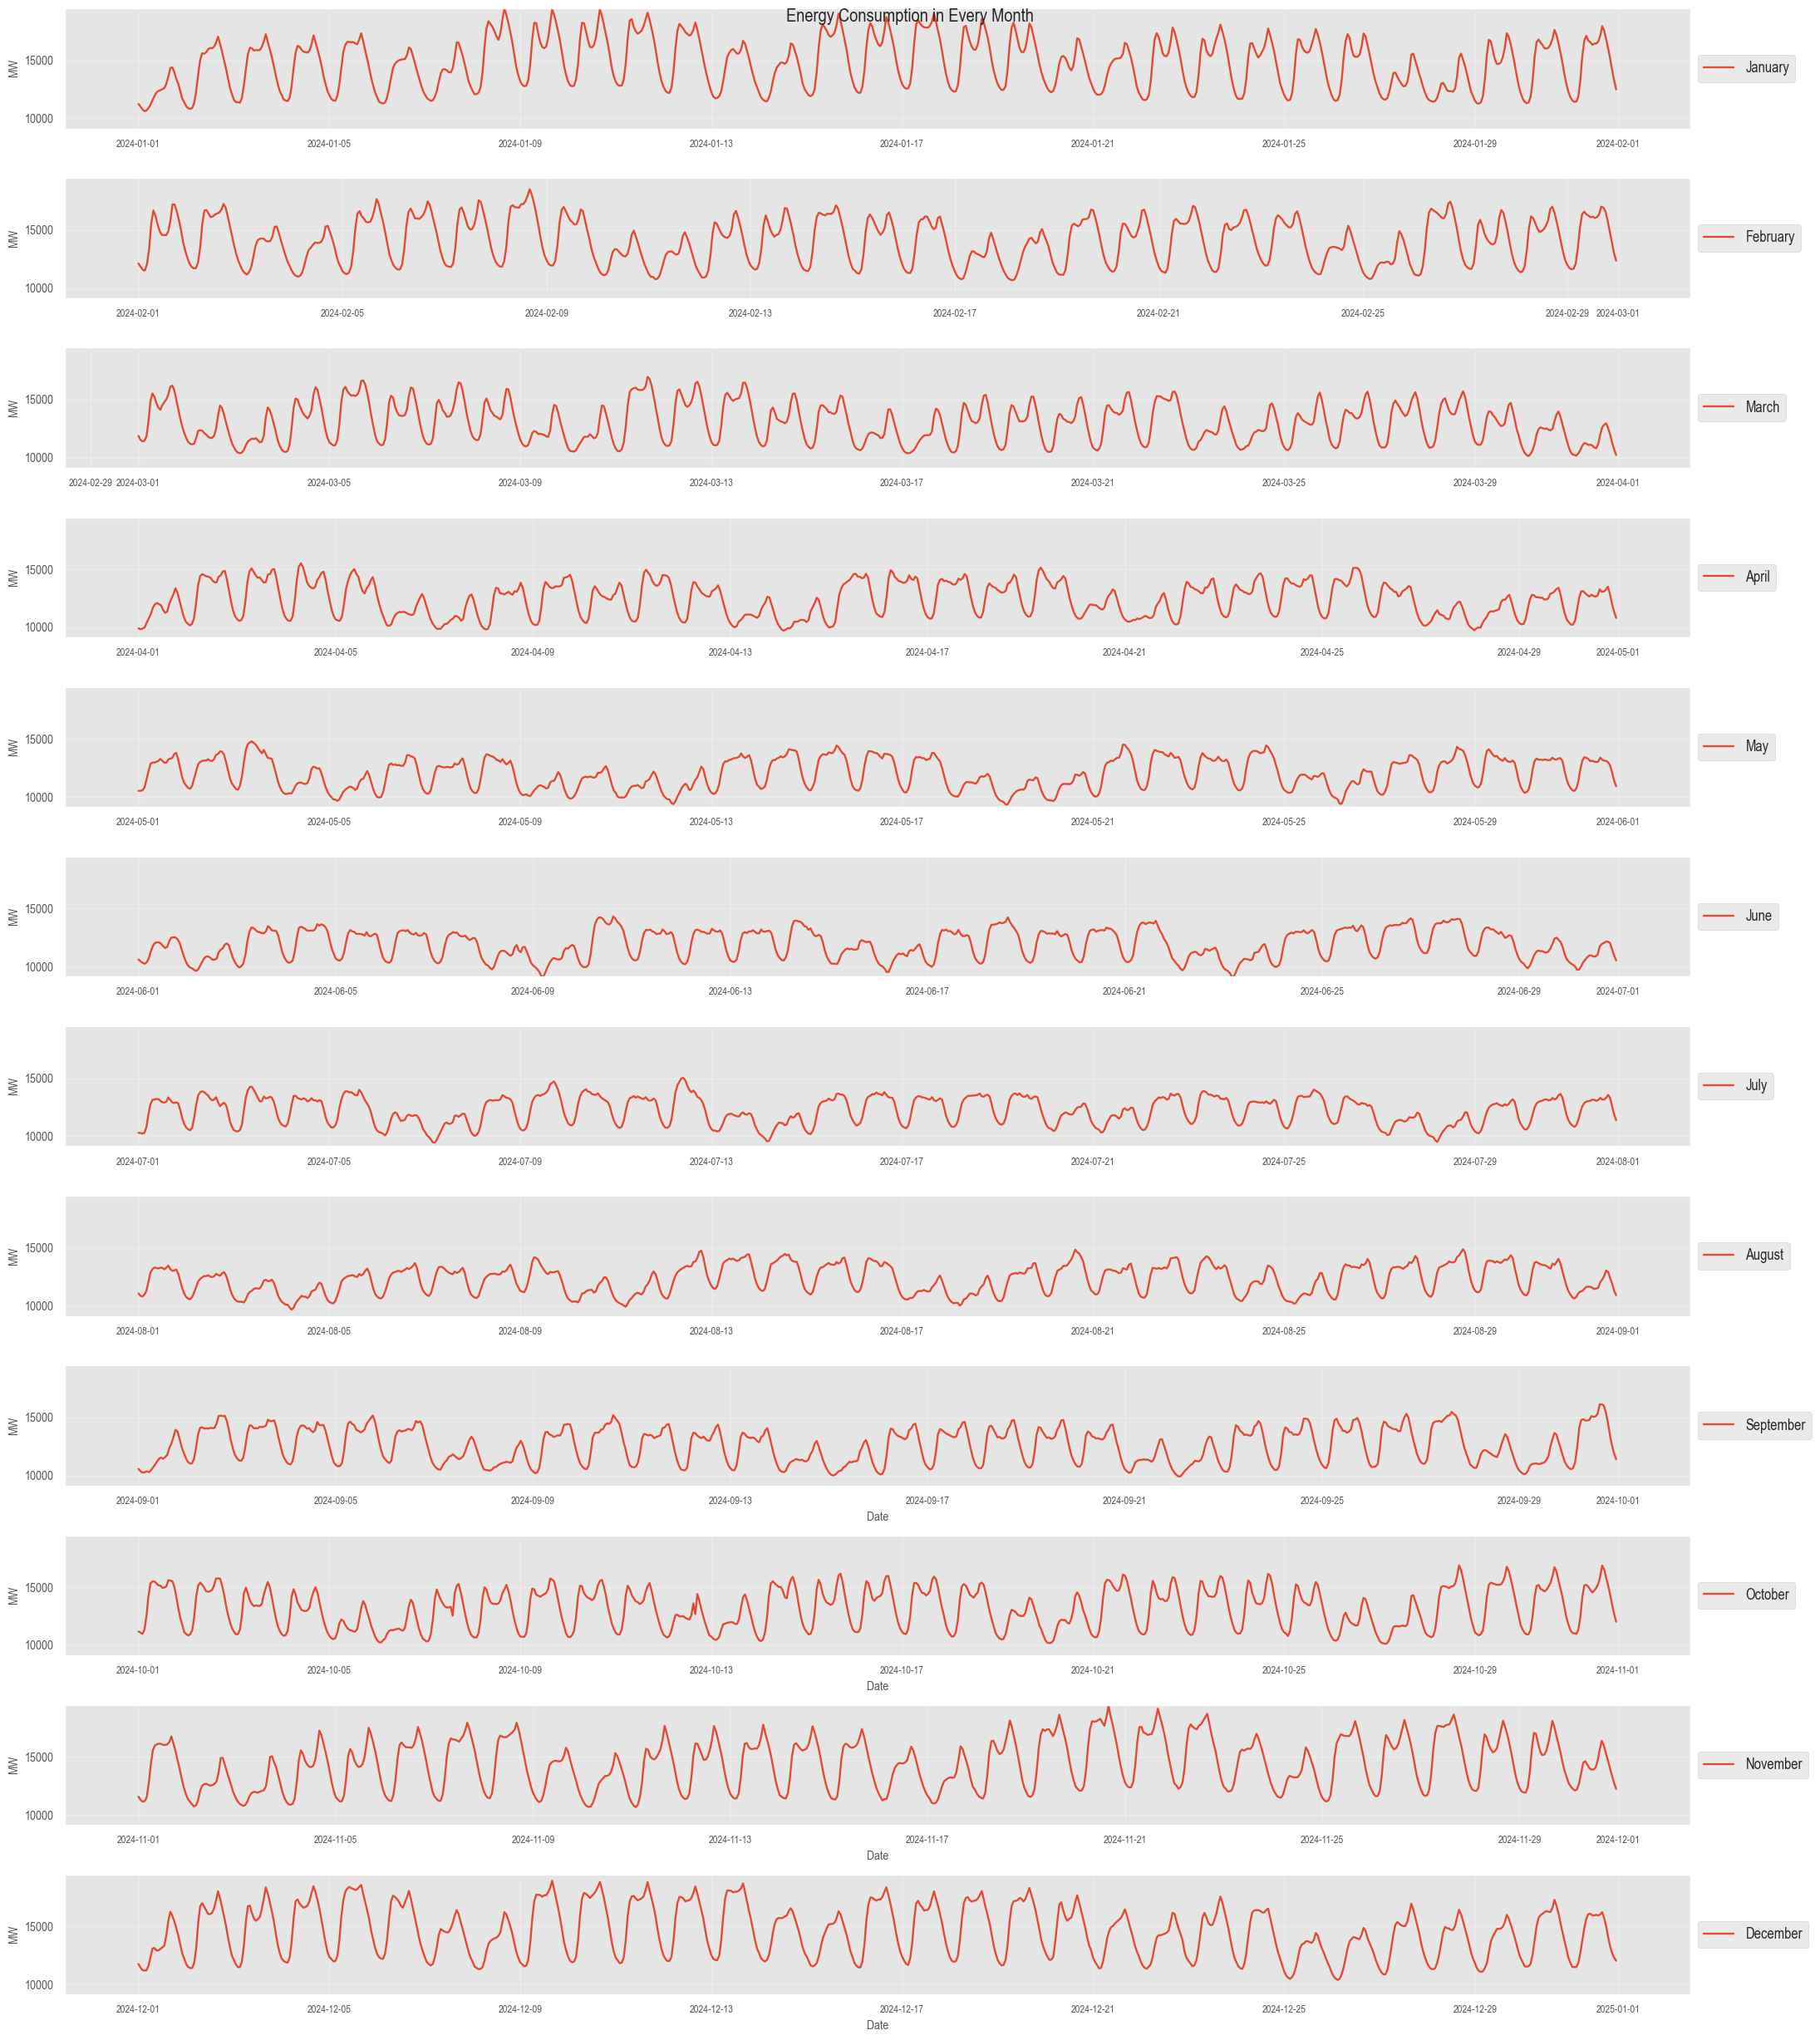

In [13]:
from matplotlib import style
style.use('ggplot')

fig, axes = plt.subplots(12, 1, figsize=(22, 25))
fig.suptitle("Energy Consumption in Every Month", fontsize=16)

months = ['January', 'February', 'March', 'April', 'May', 'June', 
          'July', 'August', 'September', 'October', 'November', 'December']

# 2. Unify Y-axis - get global min/max
y_min, y_max = df['Value'].min(), df['Value'].max()

for i in range(12):
    month_data = df[df.index.month == i+1]
    axes[i].plot(month_data.index, month_data['Value'], linewidth=1.7, label=months[i])
    axes[i].set_ylabel("MW", fontsize=11)
    axes[i].set_ylim(y_min, y_max)  # Unified Y-axis scale
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=13)
    axes[i].tick_params(axis='x', labelsize=9)

# Add x-labels to bottom row
for ax in axes[8:]:
    ax.set_xlabel("Date", fontsize=11)

plt.tight_layout()
plt.show()

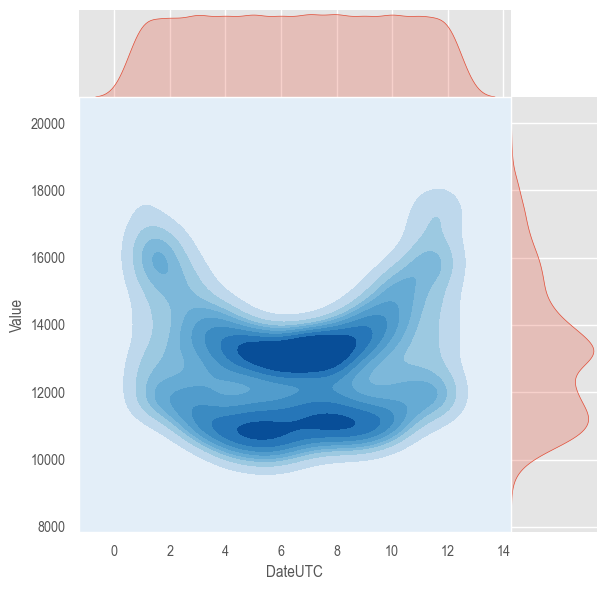

In [14]:
# Use proper continuous values instead of categorical months
sns.jointplot(x=df.index.month, y=df['Value'], kind='kde',
              space=0, fill=True, thresh=0, cmap='Blues')
plt.title("KDE Plot: Value Distribution by Month")
plt.show()

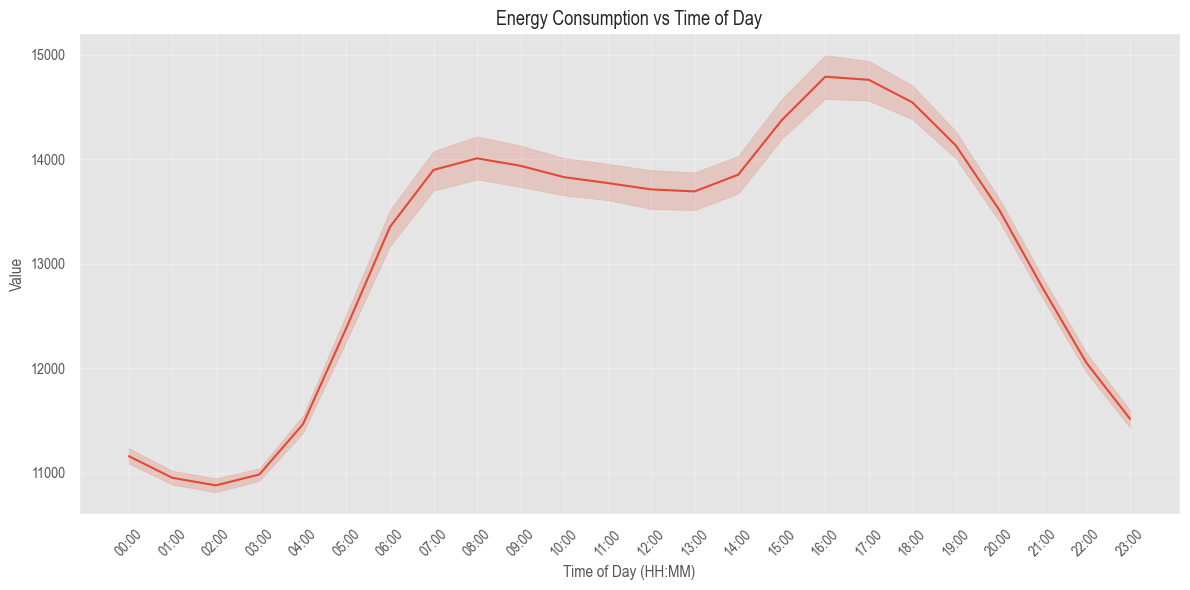

In [15]:
# Extract hour and minute for better plotting
df['Hour_Minute'] = df.index.time
df['Hour_Minute_Str'] = df['Hour_Minute'].apply(lambda x: f"{x.hour:02d}:{x.minute:02d}")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Hour_Minute_Str', y='Value')
plt.title("Energy Consumption vs Time of Day")
plt.xlabel("Time of Day (HH:MM)")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

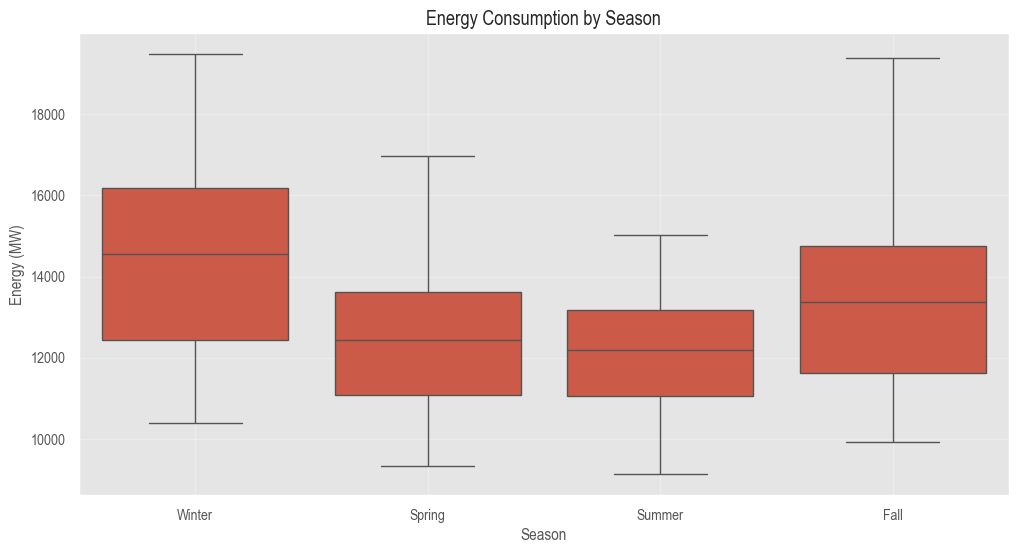

                mean          std         min        max
Season                                                  
Fall    13372.081107  1952.622295   9922.1450  19383.000
Spring  12444.384545  1543.819568   9347.1150  16963.325
Summer  12132.262566  1227.972592   9134.6425  15015.340
Winter  14456.929305  2110.554957  10393.5325  19477.155


In [16]:
# Define seasons
season_map = {
    'Winter': [12, 1, 2], 'Spring': [3, 4, 5],
    'Summer': [6, 7, 8], 'Fall': [9, 10, 11]
}

df['Season'] = df.index.month.map(
    {month: season for season, months in season_map.items() for month in months}
)

# Seasonal boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Season'], y=df['Value'], order=['Winter', 'Spring', 'Summer', 'Fall'])
plt.title('Energy Consumption by Season')
plt.ylabel('Energy (MW)')
plt.grid(True, alpha=0.3)
plt.show()

# Seasonal averages
seasonal_avg = df.groupby('Season')['Value'].agg(['mean', 'std', 'min', 'max'])
print(seasonal_avg)

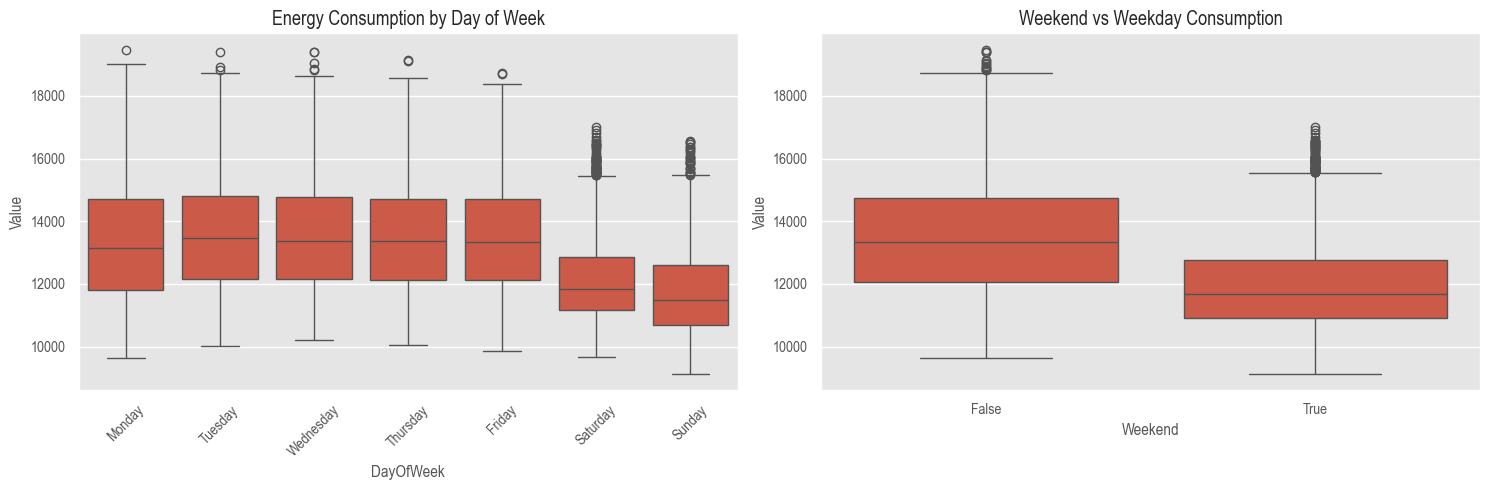

In [17]:
# Day of week analysis
df['DayOfWeek'] = df.index.day_name()
df['Weekend'] = df['DayOfWeek'].isin(['Saturday', 'Sunday'])

# Weekly patterns
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x=df['DayOfWeek'], y=df['Value'], 
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.title('Energy Consumption by Day of Week')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Weekend'], y=df['Value'])
plt.title('Weekend vs Weekday Consumption')
plt.tight_layout()
plt.show()

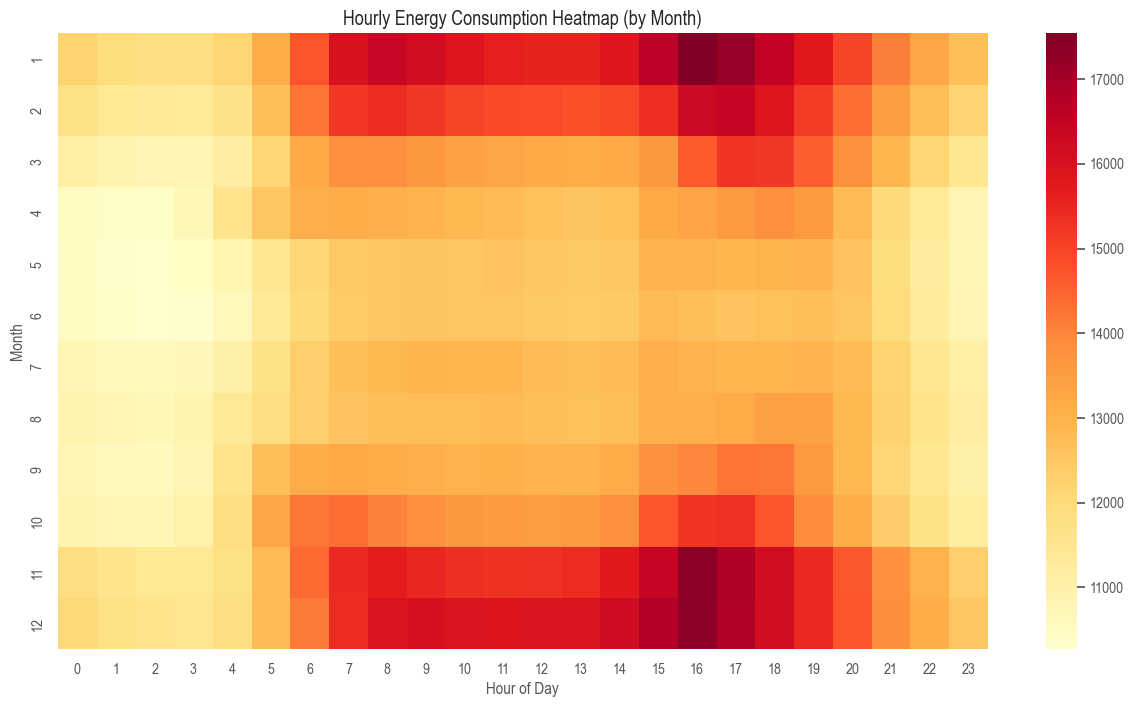

In [18]:
# Create hour-month heatmap
hourly_monthly = df.groupby([df.index.month, df.index.hour])['Value'].mean().unstack()

plt.figure(figsize=(15, 8))
sns.heatmap(hourly_monthly, cmap='YlOrRd', annot=False, fmt='.0f')
plt.title('Hourly Energy Consumption Heatmap (by Month)')
plt.ylabel('Month')
plt.xlabel('Hour of Day')
plt.show()

Peak Consumption Hours:
Hour
16    14790.914249
17    14761.601291
18    14545.762172
15    14374.456189
19    14132.722131
Name: Value, dtype: float64


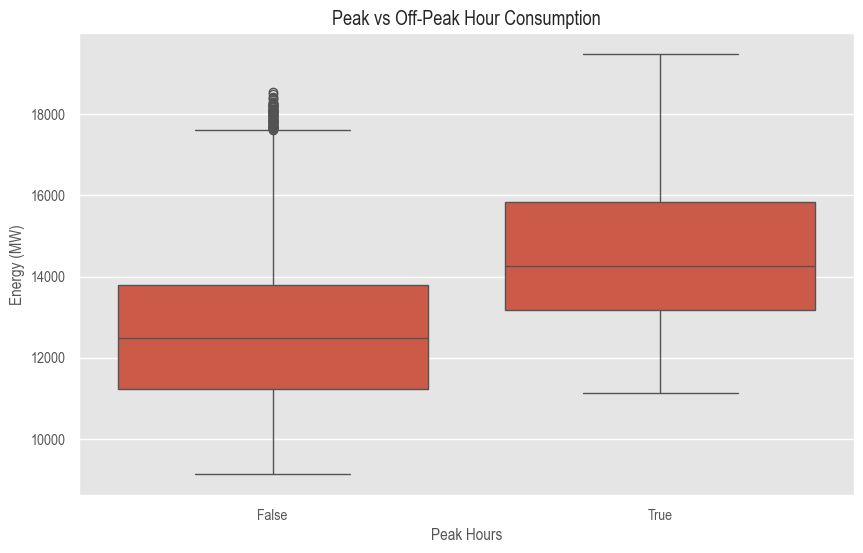

In [19]:
# Identify peak consumption periods
df['Hour'] = df.index.hour
peak_hours = df.groupby('Hour')['Value'].mean().nlargest(5)

print("Peak Consumption Hours:")
print(peak_hours)

# Peak vs Off-peak analysis
df['Peak_Hour'] = df['Hour'].isin(peak_hours.index)

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Peak_Hour'], y=df['Value'])
plt.title('Peak vs Off-Peak Hour Consumption')
plt.xlabel('Peak Hours')
plt.ylabel('Energy (MW)')
plt.show()

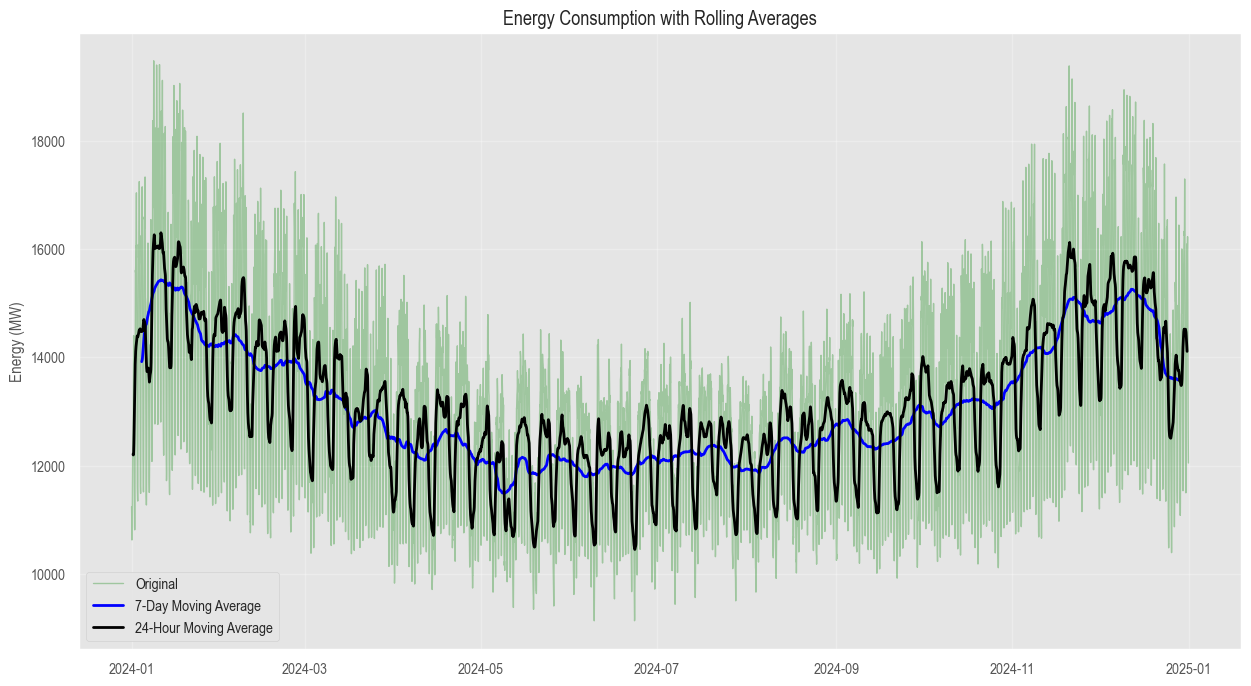

In [20]:
# Calculate rolling averages
df['7D_Avg'] = df['Value'].rolling(window=7*24, center=True).mean()  # 7-day rolling avg
df['24H_Avg'] = df['Value'].rolling(window=24, center=True).mean()   # 24-hour rolling avg

# Plot rolling averages
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['Value'], alpha=0.3, label='Original', linewidth=1, color = 'green')
plt.plot(df.index, df['7D_Avg'], label='7-Day Moving Average', linewidth=2, color = 'blue')
plt.plot(df.index, df['24H_Avg'], label='24-Hour Moving Average', linewidth=2, color = 'black')
plt.title('Energy Consumption with Rolling Averages')
plt.ylabel('Energy (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Anomalies detected: 371 (4.22%)


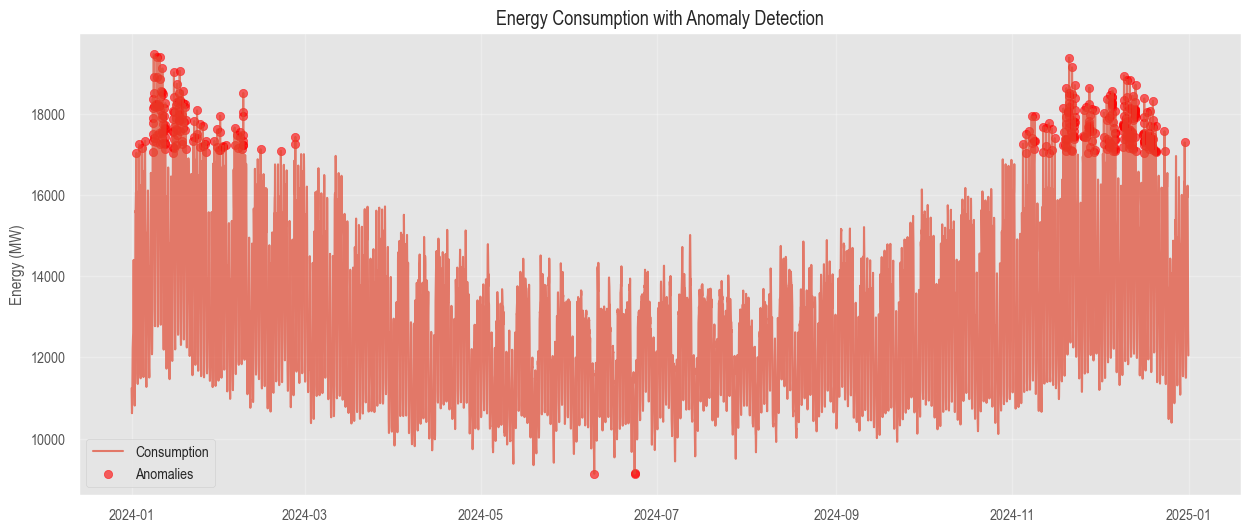

In [21]:
# Simple statistical anomaly detection
mean_val = df['Value'].mean()
std_val = df['Value'].std()
threshold = 2 * std_val

df['Anomaly'] = abs(df['Value'] - mean_val) > threshold

print(f"Anomalies detected: {df['Anomaly'].sum()} ({df['Anomaly'].sum()/len(df)*100:.2f}%)")

# Plot anomalies
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Value'], label='Consumption', alpha=0.7)
plt.scatter(df[df['Anomaly']].index, df[df['Anomaly']]['Value'], 
            color='red', label='Anomalies', alpha=0.6)
plt.title('Energy Consumption with Anomaly Detection')
plt.ylabel('Energy (MW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

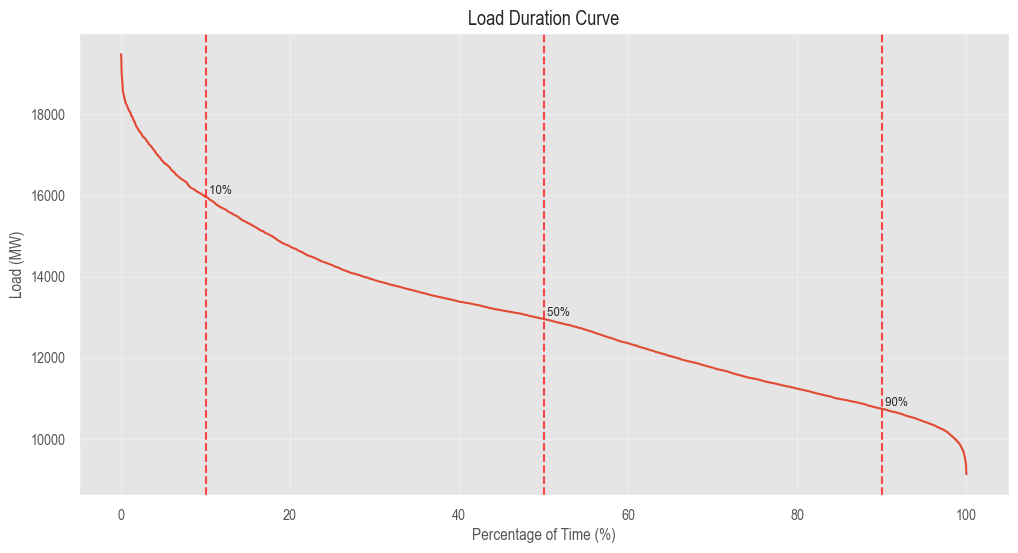

In [22]:
# Create load duration curve
sorted_load = np.sort(df['Value'])[::-1]  # Sort descending
percentiles = np.linspace(0, 100, len(sorted_load))

plt.figure(figsize=(12, 6))
plt.plot(percentiles, sorted_load)
plt.title('Load Duration Curve')
plt.xlabel('Percentage of Time (%)')
plt.ylabel('Load (MW)')
plt.grid(True, alpha=0.3)

# Mark key percentiles
for p in [10, 50, 90]:
    idx = int(p/100 * len(sorted_load))
    plt.axvline(x=p, color='red', linestyle='--', alpha=0.7)
    plt.text(p, sorted_load[idx], f' {p}%', verticalalignment='bottom')
plt.show()

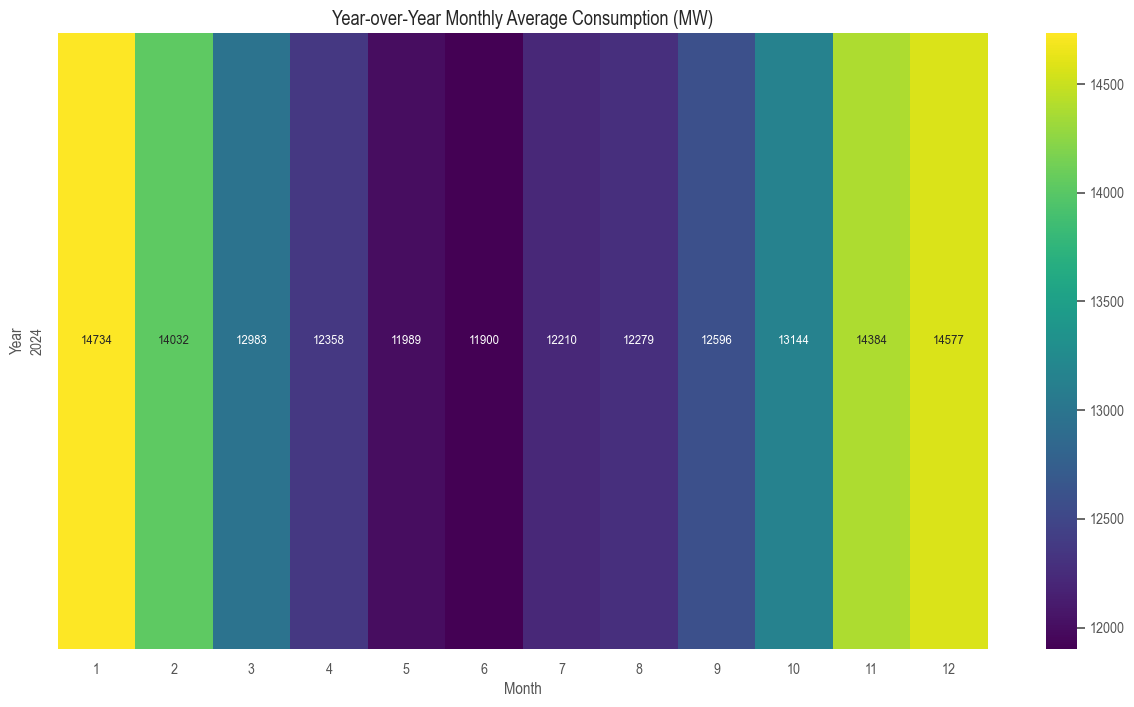

In [23]:
# Pivot table for year-month comparison
year_month_avg = df.groupby([df.index.year, df.index.month])['Value'].mean().unstack()

plt.figure(figsize=(15, 8))
sns.heatmap(year_month_avg, cmap='viridis', annot=True, fmt='.0f')
plt.title('Year-over-Year Monthly Average Consumption (MW)')
plt.ylabel('Year')
plt.xlabel('Month')
plt.show()